In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

In [3]:
dataset = load_dataset("CShorten/ML-ArXiv-Papers",split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
print(dataset)

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [5]:
dataset[0]

{'Unnamed: 0.1': 0,
 'Unnamed: 0': 0.0,
 'title': 'Learning from compressed observations',
 'abstract': '  The problem of statistical learning is to construct a predictor of a random\nvariable $Y$ as a function of a related random variable $X$ on the basis of an\ni.i.d. training sample from the joint distribution of $(X,Y)$. Allowable\npredictors are drawn from some specified class, and the goal is to approach\nasymptotically the performance (expected loss) of the best predictor in the\nclass. We consider the setting in which one has perfect observation of the\n$X$-part of the sample, while the $Y$-part has to be communicated at some\nfinite bit rate. The encoding of the $Y$-values is allowed to depend on the\n$X$-values. Under suitable regularity conditions on the admissible predictors,\nthe underlying family of probability distributions and the loss function, we\ngive an information-theoretic characterization of achievable predictor\nperformance in terms of conditional distortion-rat

In [6]:
import pandas as pd

In [7]:
df = pd.DataFrame(dataset)
df

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...,...,...
117587,4995,NaN,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,4996,NaN,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,4997,NaN,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,4998,NaN,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [8]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [9]:
df=df[['title','abstract']]

In [10]:
df

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...
117587,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [11]:
df.shape

(117592, 2)

In [12]:
df=df.head(15000)

In [13]:
df.shape

(15000, 2)

In [14]:
df.isnull().sum()

,0
title,0
abstract,0


In [15]:
df["paper_text"]=df["title"]+" "+df["abstract"]

/tmp/ipykernel_13713/529180721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["title"]+" "+df["abstract"]


In [16]:
df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [17]:
type(df[["paper_text"]])

pandas.core.frame.DataFrame

In [18]:
df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [19]:
print(df["paper_text"].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random
variable $Y$ as a function of a related random variable $X$ on the basis of an
i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable
predictors are drawn from some specified class, and the goal is to approach
asymptotically the performance (expected loss) of the best predictor in the
class. We consider the setting in which one has perfect observation of the
$X$-part of the sample, while the $Y$-part has to be communicated at some
finite bit rate. The encoding of the $Y$-values is allowed to depend on the
$X$-values. Under suitable regularity conditions on the admissible predictors,
the underlying family of probability distributions and the loss function, we
give an information-theoretic characterization of achievable predictor
performance in terms of conditional distortion-rate functions. The ideas are
illustrated on the example of nonparametric regress

In [20]:
from sentence_transformers import SentenceTransformer

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [21]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [22]:
print(type(model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [23]:
df["paper_text"]=df["paper_text"].str.replace("\n"," ",regex=False)
df["paper_text"]=df["paper_text"].str.strip()

/tmp/ipykernel_13713/2190359946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["paper_text"].str.replace("\n"," ",regex=False)
/tmp/ipykernel_13713/2190359946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["paper_text"].str.strip()


In [24]:
sample_text=df["paper_text"].iloc[0]
sample_text

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [25]:
embedding=model.encode(sample_text)
print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [26]:
embedding[:56]

array([-0.13156408, -0.00678264, -0.00367611,  0.03265159,  0.11219642,
        0.01227268,  0.09816723, -0.09005231,  0.0423116 , -0.01977348,
       -0.03308417,  0.07452946,  0.10632041, -0.0206043 , -0.02052102,
        0.00169494,  0.0708195 ,  0.05854455, -0.11231909,  0.02082473,
        0.05692543,  0.0201578 ,  0.02583109,  0.0321703 ,  0.10513762,
       -0.09676764,  0.02700803, -0.02345091, -0.04549675, -0.010137  ,
       -0.01794854, -0.04814429,  0.01077654, -0.03759069,  0.01943482,
        0.0371519 ,  0.02967845,  0.04330943,  0.04373214,  0.03704866,
       -0.00182595,  0.00455184, -0.00799067,  0.03037367, -0.014378  ,
        0.03795146,  0.05959162, -0.02583359, -0.06521574,  0.05900269,
       -0.02107136,  0.07359424, -0.05720104,  0.00294058,  0.00767514,
       -0.03334163], dtype=float32)

In [27]:
sample_embedding=model.encode(df["paper_text"].head(5).to_list())

In [28]:
print(sample_embedding.shape)

(5, 384)


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

In [30]:
similarity=cosine_similarity(sample_embedding[0].reshape(1, -1),sample_embedding[0].reshape(1, -1))
print(similarity)

[[1.]]


In [31]:
similarity=cosine_similarity(sample_embedding[0].reshape(1, -1),sample_embedding[1].reshape(1, -1))
print(similarity)

[[0.36625266]]


In [32]:
for i in range(1,5):
  sim=cosine_similarity(sample_embedding[0].reshape(1, -1),sample_embedding[i].reshape(1, -1))
  print(sim)

[[0.36625266]]
[[0.33522838]]
[[0.1550511]]
[[0.37421542]]


**Generate full embedding**

In [33]:
import os
import numpy as np

if os.path.exists("paper_embeddings.npy"):
    print("Loading saved embeddings")
    embeddings = np.load("paper_embeddings.npy")
else:
    print("Generating embeddings")
    embeddings = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )
    np.save("paper_embeddings.npy", embeddings)
    print("Embeddings saved successfully!")


Loading saved embeddings


In [34]:
print(embedding.shape)
print(type(embedding))

(384,)
<class 'numpy.ndarray'>


In [35]:
embedding.dtype

dtype('float32')

In [36]:
!pip install faiss-cpu

In [37]:
import faiss

In [38]:
import os
if os.path.exists("paper_faiss.index"):

    print("Loading existing FAISS index")
    index = faiss.read_index("paper_faiss.index")
else:
    print("Creating new FAISS index")
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(384)
    index.add(embeddings)
    faiss.write_index(index, "paper_faiss.index")
    print("FAISS index saved successfully!")

Loading existing FAISS index


In [39]:
# faiss.normalize_L2(embedding)

In [40]:
# index=faiss.IndexFlatIP(384)

In [41]:
# index.add(embedding)

In [42]:
print(index.ntotal)

15000


In [43]:
query="deep learning for medical image analysis"
query_embedding=model.encode([query])
query_embedding.shape

(1, 384)

In [44]:
faiss.normalize_L2(query_embedding)

In [45]:
D,I=index.search(query_embedding,5)
print(D)
print(I)

[[0.6807244  0.67092204 0.65219986 0.6281174  0.6131152 ]]
[[10466 13730 11873 12691 11282]]


In [46]:
print(df.iloc[11873]["title"])

Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection


In [47]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [48]:
print(df.iloc[10466]["title"])

A Perspective on Deep Imaging


In [49]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,5)
  return D,I


In [50]:
D,I=search_paper("deep learning for medical image analysis")
print(D)
print(I)

[[0.6807244  0.67092204 0.65219986 0.6281174  0.6131152 ]]
[[10466 13730 11873 12691 11282]]


In [51]:
def search_paper(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,5)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])
    print()

In [52]:
search_paper("deep learning for medical image analysis")

Similarity score 0.6807244
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Similarity score 0.67092204
Title Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a

In [53]:
!pip install transformers==4.46.3

In [54]:
from transformers import pipeline
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [55]:
type(summarizer)

transformers.pipelines.text2text_generation.SummarizationPipeline

In [56]:
summary=summarizer(df.iloc[10466]["abstract"],max_length=120,min_length=40)
print(summary)

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]


In [57]:
type(summary)

list

In [58]:
type(summary[0])

dict

In [59]:
summary[0]["summary_text"]

'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'

In [60]:
for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])

    summary=summarizer(df.iloc[idx]["abstract"],max_length=120,min_length=40)
    print(summary)
    print(summary[0]["summary_text"])
    print()

Similarity score 0.6807244
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance
[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]
The combination of tomographic imaging and deep learning, or mac

In [61]:
def search_and_summarize(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,5)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])
    print()


    summary=summarizer(df.iloc[idx]["abstract"],max_length=120,min_length=40,do_sample=False)
    print(summary)
    print(summary[0]["summary_text"])
    print()

In [62]:
search_and_summarize("Deep learning in medical imaging",k=5)

Similarity score 0.7354986
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]
The combination of tomographic imaging and deep learning, or ma

In [63]:
pip install Keybert==0.8.5

In [64]:
from keybert import KeyBERT

In [65]:
kw_model = KeyBERT(model)

In [66]:
type(kw_model)

keybert._model.KeyBERT

In [67]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [68]:
text=df.iloc[10466]["abstract"]
keywords = kw_model.extract_keywords(text)

In [69]:
print(keywords)

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]


In [70]:
print(type(keywords))

<class 'list'>


In [71]:
print(type(keywords[0]))

<class 'tuple'>


In [72]:
keywords=kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 3), stop_words="english")

In [73]:
print(keywords)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


In [74]:
def search_and_summarize(query,k=5):
  query_embedding=model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,5)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])
    print()


    summary=summarizer(df.iloc[idx]["abstract"],max_length=120,min_length=40,do_sample=False)
    print(summary)
    print(summary[0]["summary_text"])
    print()
    keywords=kw_model.extract_keywords(df.iloc[idx]["abstract"], keyphrase_ngram_range=(1, 3), stop_words="english")
    print(keywords)
    for k,s in keywords:
      print(k)

In [75]:
search_and_summarize("deep learning for medical image analysis", k=3)


Similarity score 0.6807244
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]
The combination of tomographic imaging and deep learning, or ma

## Named Entity Recognition (NER)
Custom NER model trained from scratch on our own ArXiv ML abstracts (no generic pretrained model).

In [76]:
!pip install spacy -q
import spacy
import random
import re
from spacy.training import Example


In [77]:
# STEP 1: Auto-generate labeled training data from OUR OWN abstracts.
# The seed_terms dict is used only ONCE, offline, to locate real occurrences
# of these words inside our abstracts and label them in context.
# It is NOT used at inference/prediction time.
seed_terms = {
    "PROGRAMMING_LANGUAGE": ["Python", "Java", "C++", "MATLAB", "R "],
    "ORGANIZATION": ["Google", "Microsoft", "OpenAI", "Facebook", "IBM"],
    "FRAMEWORK": ["TensorFlow", "PyTorch", "Keras", "Scikit-learn"],
    "DATASET": ["ImageNet", "MNIST", "COCO", "CIFAR-10"],
    "MODEL": ["BERT", "ResNet", "LSTM", "Transformer", "CNN"],
}

def build_training_data(df, seed_terms, max_examples=300):
    training_data = []
    for abstract in df["abstract"].dropna():
        abstract = abstract.strip()
        if not abstract:
            continue
        found_entities = []
        for label, terms in seed_terms.items():
            for term in terms:
                for match in re.finditer(re.escape(term), abstract):
                    start, end = match.start(), match.end()
                    found_entities.append((start, end, label))
        if found_entities:
            found_entities = sorted(found_entities, key=lambda x: x[0])
            clean_entities = []
            last_end = -1
            for start, end, label in found_entities:
                if start >= last_end:
                    clean_entities.append((start, end, label))
                    last_end = end
            training_data.append((abstract, {"entities": clean_entities}))
        if len(training_data) >= max_examples:
            break
    return training_data

TRAIN_DATA = build_training_data(df, seed_terms, max_examples=800)
print(f"Built {len(TRAIN_DATA)} training examples from our own dataset")
print(TRAIN_DATA[0])


Built 800 training examples from our own dataset
('In a sensor network, in practice, the communication among sensors is subject\nto:(1) errors or failures at random times; (3) costs; and(2) constraints since\nsensors and networks operate under scarce resources, such as power, data rate,\nor communication. The signal-to-noise ratio (SNR) is usually a main factor in\ndetermining the probability of error (or of communication failure) in a link.\nThese probabilities are then a proxy for the SNR under which the links operate.\nThe paper studies the problem of designing the topology, i.e., assigning the\nprobabilities of reliable communication among sensors (or of link failures) to\nmaximize the rate of convergence of average consensus, when the link\ncommunication costs are taken into account, and there is an overall\ncommunication budget constraint. To consider this problem, we address a number\nof preliminary issues: (1) model the network as a random topology; (2)\nestablish necessary and

In [78]:
# STEP 2: Build a completely blank pipeline (no pretrained weights at all)
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner")

labels = ["PROGRAMMING_LANGUAGE", "ORGANIZATION", "FRAMEWORK", "DATASET", "MODEL"]
for label in labels:
    ner.add_label(label)


In [80]:
# STEP 3: Train from scratch, learning purely from our own abstracts
optimizer = nlp.begin_training()

n_iter = 60
for epoch in range(n_iter):
    random.shuffle(TRAIN_DATA)
    losses = {}
    for text, annotations in TRAIN_DATA:
        doc = nlp.make_doc(text)
        try:
            example = Example.from_dict(doc, annotations)
            nlp.update([example], sgd=optimizer, losses=losses, drop=0.3)
        except Exception:
            continue
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Losses: {losses}")


Epoch 0, Losses: {'ner': np.float32(1535.2606)}
Epoch 5, Losses: {'ner': np.float32(59.492302)}
Epoch 10, Losses: {'ner': np.float32(28.187584)}
Epoch 15, Losses: {'ner': np.float32(23.182577)}
Epoch 20, Losses: {'ner': np.float32(16.662382)}
Epoch 25, Losses: {'ner': np.float32(13.923033)}
Epoch 30, Losses: {'ner': np.float32(3.5112425e-08)}
Epoch 35, Losses: {'ner': np.float32(2.009423)}
Epoch 40, Losses: {'ner': np.float32(2.151916)}
Epoch 45, Losses: {'ner': np.float32(13.531885)}
Epoch 50, Losses: {'ner': np.float32(8.142571)}
Epoch 55, Losses: {'ner': np.float32(2.0130632)}


In [81]:
# STEP 4: Model predicts entities on its own, no lookup at inference time
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

sample_train_text = TRAIN_DATA[0][0]
print("Text:", sample_train_text[:200])
print("Predicted entities:", extract_entities(sample_train_text))

found_count = 0
for abstract in df["abstract"].dropna().head(500):
    ents = extract_entities(abstract)
    if ents:
        print(abstract[:150], "->", ents)
        found_count += 1
    if found_count >= 5:
        break


Text: It has been a long time, since data mining technologies have made their ways
to the field of data management. Classification is one of the most important
data mining tasks for label prediction, catego
Predicted entities: [('MATLAB', 'PROGRAMMING_LANGUAGE')]
  Support vector machines (SVMs) are an extremely successful type of
classification and regression algorithms. Building an SVM entails solving a
const -> [('IBM', 'ORGANIZATION')]
  We give polynomial-time algorithms for the exact computation of lowest-energy
(ground) states, worst margin violators, log partition functions, and  -> [('C++', 'PROGRAMMING_LANGUAGE')]
  Networks are ubiquitous in science and have become a focal point for
discussion in everyday life. Formal statistical models for the analysis of
netw -> [('Facebook', 'ORGANIZATION')]
  In this paper, the framework of kernel machines with two layers is
introduced, generalizing classical kernel methods. The new learning methodology
p -> [('MATLAB', 'PROGRAMMING_LANG

In [ ]:
df["entities"] = df["abstract"].apply(extract_entities)
df[["title", "entities"]].head()


## Feature: Topic Clustering & Visualization
Group papers into research topic clusters using the embeddings we already computed for search, then visualize them in 2D.

In [82]:
!pip install scikit-learn matplotlib -q

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Cluster papers using the SAME embeddings already built for FAISS search
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(embeddings)


/tmp/ipykernel_13713/2951425668.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cluster"] = kmeans.fit_predict(embeddings)


In [83]:
# Label each cluster using top KeyBERT keywords from its papers
def label_cluster(cluster_id, n_papers=15):
    sample_abstracts = df[df["cluster"] == cluster_id]["abstract"].head(n_papers).tolist()
    combined_text = " ".join(sample_abstracts)
    keywords = kw_model.extract_keywords(combined_text, keyphrase_ngram_range=(1, 2),
                                          stop_words="english", top_n=3)
    return ", ".join([kw for kw, score in keywords])

cluster_labels = {i: label_cluster(i) for i in range(n_clusters)}
for cid, label in cluster_labels.items():
    print(f"Cluster {cid}: {label}")


Cluster 0: predictions features, ranking bioinformatics, classification regression
Cluster 1: information theoretic, admissible predictors, statistical learning
Cluster 2: rules semantic, rules semantically, semantic relations
Cluster 3: correlation clustering, clusters graphs, modern clustering
Cluster 4: carlo optimization, exploit sample, immediate sampling
Cluster 5: reliable communication, random network, network random
Cluster 6: decision processes, information behavior, knowledge decision
Cluster 7: definition entropy, entropy define, entropy


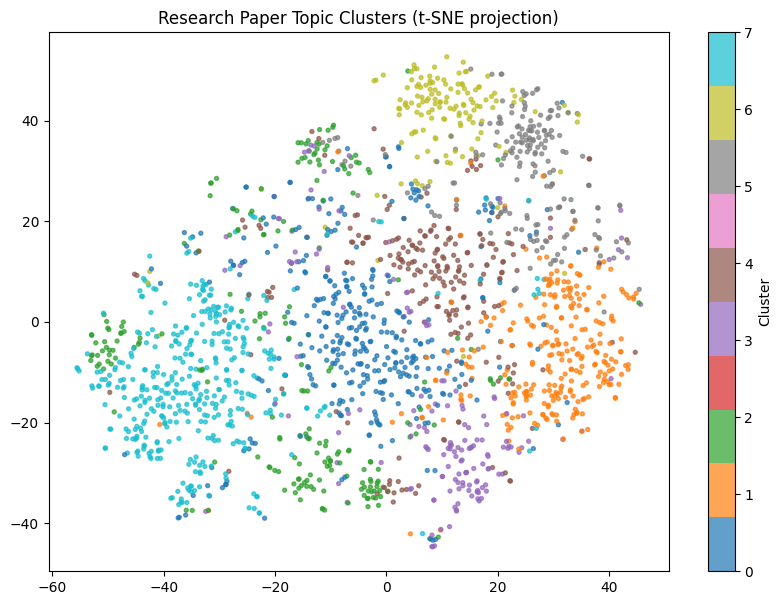

In [84]:
# Visualize clusters in 2D using t-SNE
sample_size = min(2000, len(embeddings))
idx_sample = np.random.choice(len(embeddings), sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embeddings[idx_sample])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1],
                       c=df["cluster"].iloc[idx_sample], cmap="tab10", s=8, alpha=0.7)
plt.title("Research Paper Topic Clusters (t-SNE projection)")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [85]:
# Given a search result index, show which topic cluster it belongs to
def get_paper_topic(idx):
    cluster_id = df.iloc[idx]["cluster"]
    return cluster_labels[cluster_id]


## Feature: Interactive Demo UI (Gradio)
Combine search, summarization, keyword extraction, NER, and topic clustering into one interactive app.

In [1]:
!pip uninstall -y gradio gradio_client
!pip install gradio==5.9.1

Found existing installation: gradio 5.9.1
Uninstalling gradio-5.9.1:
  Successfully uninstalled gradio-5.9.1
Found existing installation: gradio_client 1.5.2
Uninstalling gradio_client-1.5.2:
  Successfully uninstalled gradio_client-1.5.2
  Using cached gradio-5.9.1-py3-none-any.whl.metadata (16 kB)
  Using cached gradio_client-1.5.2-py3-none-any.whl.metadata (7.1 kB)
Using cached gradio-5.9.1-py3-none-any.whl (57.2 MB)
Using cached gradio_client-1.5.2-py3-none-any.whl (320 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.5.2 which is incompatible.


In [8]:
# !pip install gradio -q

import gradio as gr

def full_pipeline(query, top_k):
    print("Function Called")
    return "Working"
    query_embedding = model.encode([query])
    print(query_embedding.shape)
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, top_k)
    print(D)
    print(I)

    results = ""
    for score, idx in zip(D[0], I[0]):
        abstract = df.iloc[idx]["abstract"]
        title = df.iloc[idx]["title"]
        summary = summarizer(abstract, max_length=120, min_length=40, do_sample=False)[0]["summary_text"]
        keywords = kw_model.extract_keywords(abstract, keyphrase_ngram_range=(1, 3), stop_words="english", top_n=5)
        entities = extract_entities(abstract)
        topic = get_paper_topic(idx)

        results += f"### {title}\n"
        results += f"**Similarity score:** {score:.3f} | **Topic:** {topic}\n\n"
        results += f"**Summary:** {summary}\n\n"
        results += f"**Keywords:** {', '.join([k for k,s in keywords])}\n\n"
        results += f"**Entities:** {entities}\n\n---\n\n"
    return results

demo = gr.Interface(
    fn=full_pipeline,
    inputs=[
        gr.Textbox(label="Search Query", placeholder="e.g. transformer models for image classification"),
        gr.Slider(1, 10, value=3, step=1, label="Number of results")
    ],
    outputs=gr.Markdown(label="Results"),
    title="AI Research Paper Search Engine",
    description="Semantic search + summarization + keyword extraction + NER + topic clustering over ArXiv ML papers"
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a18bf22be568f09273.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
